# Clustering
___

In [1]:
#Library Import
import os
from pathlib import Path
from subprocess import call
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from typing import List, Tuple
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, AffinityPropagation, MeanShift, SpectralClustering, AgglomerativeClustering, DBSCAN
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.mixture import GaussianMixture
from sklearn.cluster import Birch
import random
from PIL import Image

#### Code

In [2]:
def color_clustering(image_path, n_clusters=5):
    #Read image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    #Reshape image data into 2D array, each row represents RGB values of a pixel
    pixels = image.reshape(-1, 3)
    
    #Apply K-means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(pixels)
    
    #Get cluster centers (main colors)
    colors = kmeans.cluster_centers_
    
    #Calculate the number of pixels in each cluster
    labels = kmeans.labels_
    counts = np.bincount(labels)
    percentages = counts / len(labels) * 100
    
    #Visualize results
    plt.figure(figsize=(16, 4))
    
    #Original image
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title('Original Image')
    plt.axis('off')
    
    #Color bar chart
    plt.subplot(1, 2, 2)
    
    #Create color bars
    color_bars = np.zeros((100, 500, 3))
    start = 0
    
    #Sort by color proportion
    color_percent = list(zip(colors, percentages))
    color_percent.sort(key=lambda x: x[1], reverse=True)
    
    for color, percent in color_percent:
        end = start + (percent/100)*color_bars.shape[1]
        color_bars[:, int(start):int(end)] = color
        start = end
    
    plt.imshow(color_bars.astype(np.uint8))
    plt.title('Color Distribution')
    
    return colors, percentages

In [18]:
def load_and_prepare_image(image_path):
    # Read and convert image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Reshape and scale the data
    pixels = image.reshape(-1, 3)
    scaler = StandardScaler()
    pixels_scaled = scaler.fit_transform(pixels)
    
    return image, pixels, pixels_scaled, scaler

def visualize_clusters(image, pixels, labels, centers=None, title="Clustering Result"):
    # Reconstruct the image with cluster colors
    if centers is not None:
        # Use cluster centers as colors
        clustered = centers[labels].reshape(image.shape)
    else:
        # Calculate mean color for each cluster
        unique_labels = np.unique(labels)
        centers = np.array([pixels[labels == label].mean(axis=0) for label in unique_labels])
        clustered = centers[labels].reshape(image.shape)
    
    # Create color distribution bar
    unique_labels = np.unique(labels)
    percentages = np.array([(labels == label).sum() / len(labels) * 100 for label in unique_labels])
    
    # Sort colors by percentage
    sort_idx = np.argsort(percentages)[::-1]
    percentages = percentages[sort_idx]
    centers = centers[sort_idx]
    
    # Create color bar
    color_bars = np.zeros((100, 500, 3))
    start = 0
    for i, percent in enumerate(percentages):
        end = start + (percent/100)*color_bars.shape[1]
        color_bars[:, int(start):int(end)] = centers[i]
        start = end
    
    # Plotting
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(clustered.astype(np.uint8))
    plt.title(f'{title}\n{len(unique_labels)} clusters')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(color_bars.astype(np.uint8))
    plt.title('Color Distribution')
    
    # Add percentage labels
    start = 0
    for i, percent in enumerate(percentages):
        plt.text(start + (percent/100)*color_bars.shape[1]/2, 120, 
                f'{percent:.1f}%', ha='center', va='center')
        start = start + (percent/100)*color_bars.shape[1]
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def analyze_kmeans(image_path): #K-Means
    image, pixels, pixels_scaled, scaler = load_and_prepare_image(image_path)
    kmeans = KMeans(n_clusters=5, random_state=42)
    kmeans_labels = kmeans.fit_predict(pixels)
    kmeans_centers = kmeans.cluster_centers_
    visualize_clusters(image, pixels, kmeans_labels, kmeans_centers, "K-means Clustering")

def analyze_gmm(image_path): #Gaussian Mixture Model
    image, pixels, pixels_scaled, scaler = load_and_prepare_image(image_path)
    gmm = GaussianMixture(n_components=5, random_state=42)
    gmm_labels = gmm.fit_predict(pixels_scaled)
    gmm_centers = scaler.inverse_transform(gmm.means_)
    visualize_clusters(image, pixels, gmm_labels, gmm_centers, "Gaussian Mixture Model")

def analyze_meanshift(image_path): #Meanshift
    image, pixels, pixels_scaled, scaler = load_and_prepare_image(image_path)
    bandwidth = estimate_bandwidth(pixels_scaled, quantile=0.2, n_samples=500)
    ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    ms_labels = ms.fit_predict(pixels_scaled)
    ms_centers = scaler.inverse_transform(ms.cluster_centers_)
    visualize_clusters(image, pixels, ms_labels, ms_centers, "Mean Shift Clustering")

In [19]:
def image_aggolomerative(image_path):
    # Read and convert image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Flatten image and scale
    pixels = image.reshape(-1, 3)
    scaler = StandardScaler()
    
    # Sample a subset of pixels
    sampled_indices = np.random.choice(pixels.shape[0], size=10000, replace=False)
    pixels_sampled = pixels[sampled_indices]
    pixels_scaled = scaler.fit_transform(pixels_sampled)

    return image, pixels, pixels_scaled, scaler, sampled_indices

def analyze_agglomerative(image_path):
    # Load and prepare the image
    image, pixels, pixels_scaled, scaler, sampled_indices = image_aggolomerative(image_path)
    
    # Perform Agglomerative Clustering on the sampled data
    agg = AgglomerativeClustering(n_clusters=5)
    agg_labels = agg.fit_predict(pixels_scaled)
    
    # Map the sampled labels back to the original pixel array
    full_labels = np.zeros(pixels.shape[0], dtype=int)
    full_labels[sampled_indices] = agg_labels

    visualize_clusters(image, pixels, full_labels, None, "Agglomerative Clustering")

In [20]:
def image_for_dbscan(image_path, max_size=(500, 500)):
    image = Image.open(image_path).convert("RGB")
    image.thumbnail(max_size)  # Resize image to max dimensions
    pixels = np.array(image)
    pixels = pixels.reshape(-1, 3)  # Flatten the image array
    scaler = StandardScaler()
    pixels_scaled = scaler.fit_transform(pixels)
    return image, pixels, pixels_scaled, scaler

def sample_pixels(pixels, pixels_scaled, sample_size=10000):
    if len(pixels) > sample_size:
        indices = np.random.choice(len(pixels), size=sample_size, replace=False)
        pixels = pixels[indices]
        pixels_scaled = pixels_scaled[indices]
    return pixels, pixels_scaled

def analyze_dbscan(image_path):
    # Load and preprocess the image
    image, pixels, pixels_scaled, scaler = image_for_dbscan(image_path, max_size=(500, 500))
    
    # Randomly sample pixels and their scaled versions
    pixels, pixels_scaled = sample_pixels(pixels, pixels_scaled, sample_size=10000)
    
    # Apply DBSCAN
    dbscan = DBSCAN(eps=0.5, min_samples=200)
    dbscan_labels = dbscan.fit_predict(pixels_scaled)
    
    # Visualize clusters using the pixels array shape
    visualize_clusters_dbscan(image, pixels, dbscan_labels, None, "DBSCAN Clustering")

def visualize_clusters_dbscan(image, pixels, labels, centers=None, title="Clustering Result"):
    # Reconstruct the image with cluster colors
    if centers is not None:
        # Use cluster centers as colors
        clustered = centers[labels].reshape(pixels.shape[0], -1, 3)  # Fix reshaping here
    else:
        # Calculate mean color for each cluster
        unique_labels = np.unique(labels)
        centers = np.array([pixels[labels == label].mean(axis=0) for label in unique_labels])
        clustered = centers[labels].reshape(pixels.shape[0], -1, 3)  # Fix reshaping here
    
    # Create color distribution bar
    unique_labels = np.unique(labels)
    percentages = np.array([(labels == label).sum() / len(labels) * 100 for label in unique_labels])
   
    # Sort colors by percentage
    sort_idx = np.argsort(percentages)[::-1]
    percentages = percentages[sort_idx]
    centers = centers[sort_idx]
    
    # Create color bar
    color_bars = np.zeros((100, 500, 3))
    start = 0
    for i, percent in enumerate(percentages):
        end = start + (percent/100)*color_bars.shape[1]
        color_bars[:, int(start):int(end)] = centers[i]
        start = end
    
    # Plotting
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(clustered.astype(np.uint8))
    plt.title(f'{title}\n{len(unique_labels)} clusters')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(color_bars.astype(np.uint8))
    plt.title('Color Distribution')
    
    # Add percentage labels
    start = 0
    for i, percent in enumerate(percentages):
        plt.text(start + (percent/100)*color_bars.shape[1]/2, 120, 
                f'{percent:.1f}%', ha='center', va='center')
        start = start + (percent/100)*color_bars.shape[1]
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [21]:
def image_birch(image_path):
    # Read and convert image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Flatten image and scale
    pixels = image.reshape(-1, 3)
    scaler = StandardScaler()
    
    # Sample a subset of pixels
    sampled_indices = np.random.choice(pixels.shape[0], size=10000, replace=False)
    pixels_sampled = pixels[sampled_indices]
    pixels_scaled = scaler.fit_transform(pixels_sampled)

    return image, pixels, pixels_scaled, scaler, sampled_indices

def analyze_birch(image_path):
    # Load and prepare the image
    image, pixels, pixels_scaled, scaler, sampled_indices = image_birch(image_path)
    
    # Perform BIRCH on the sampled data
    birch_model = Birch(n_clusters=5, threshold=0.5)  # Adjust n_clusters and threshold as needed
    birch_labels = birch_model.fit_predict(pixels_scaled)
    
    # Map the sampled labels back to the original pixel array
    full_labels = np.zeros(pixels.shape[0], dtype=int)
    full_labels[sampled_indices] = birch_labels

    # Visualize clusters
    visualize_clusters_birch(image, pixels, full_labels, birch_model.subcluster_centers_, "BIRCH Clustering")

def visualize_clusters_birch(image, pixels, labels, centers=None, title="Clustering Result"):
    # Reconstruct the image with cluster colors
    if centers is not None:
        # Use cluster centers as colors
        clustered = centers[labels].reshape(pixels.shape[0], -1, 3)  # Fix reshaping here
    else:
        # Calculate mean color for each cluster
        unique_labels = np.unique(labels)
        centers = np.array([pixels[labels == label].mean(axis=0) for label in unique_labels])
        clustered = centers[labels].reshape(pixels.shape[0], -1, 3)  # Fix reshaping here
    
    # Create color distribution bar
    unique_labels = np.unique(labels)
    percentages = np.array([(labels == label).sum() / len(labels) * 100 for label in unique_labels])
   
    # Sort colors by percentage
    sort_idx = np.argsort(percentages)[::-1]
    percentages = percentages[sort_idx]
    centers = centers[sort_idx]
    
    # Create color bar
    color_bars = np.zeros((100, 500, 3))
    start = 0
    for i, percent in enumerate(percentages):
        end = start + (percent/100)*color_bars.shape[1]
        color_bars[:, int(start):int(end)] = centers[i]
        start = end
    
    # Plotting
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(clustered.astype(np.uint8))
    plt.title(f'{title}\n{len(unique_labels)} clusters')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(color_bars.astype(np.uint8))
    plt.title('Color Distribution')
    
    # Add percentage labels
    start = 0
    for i, percent in enumerate(percentages):
        plt.text(start + (percent/100)*color_bars.shape[1]/2, 120, 
                f'{percent:.1f}%', ha='center', va='center')
        start = start + (percent/100)*color_bars.shape[1]
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

#### Execute

In [7]:
#Variable
image_path = r'Museum_Collection_Sample.jpg'

Dominant color percentages:

[R,G,B]: [220 167  93]
Percentage: 8.0%

[R,G,B]: [0 0 0]
Percentage: 63.1%

[R,G,B]: [132  94  41]
Percentage: 8.0%

[R,G,B]: [191 134  56]
Percentage: 11.3%

[R,G,B]: [62 50 28]
Percentage: 9.6%



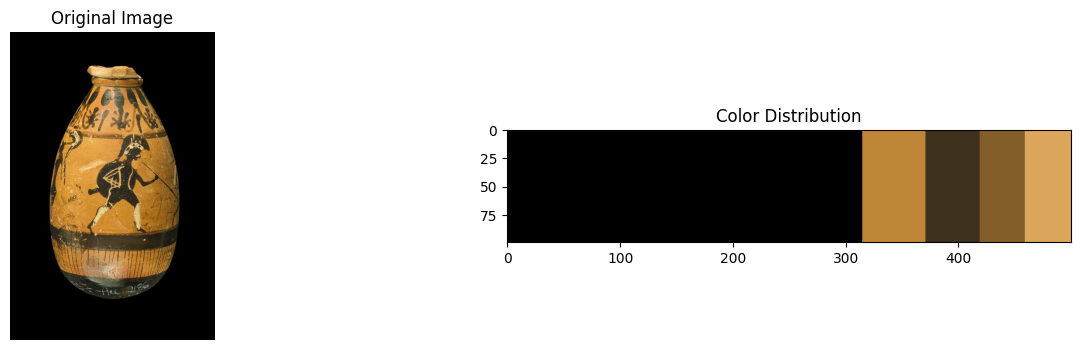

In [7]:
dominant_colors, color_percentages = color_clustering(image_path)
print("Dominant color percentages:\n")
for color, percentage in zip(dominant_colors, color_percentages):
    print(f"[R,G,B]: {color.astype(int)}\nPercentage: {percentage:.1f}%\n")

1. K-Means

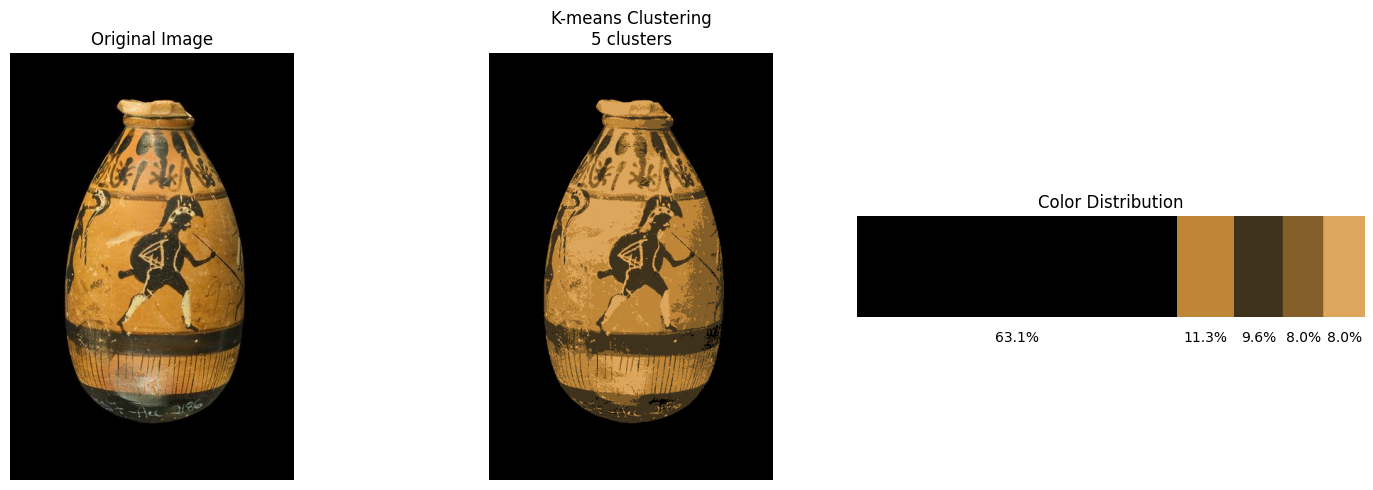

In [8]:
analyze_kmeans(image_path)

2. Gaussian Mixture Model

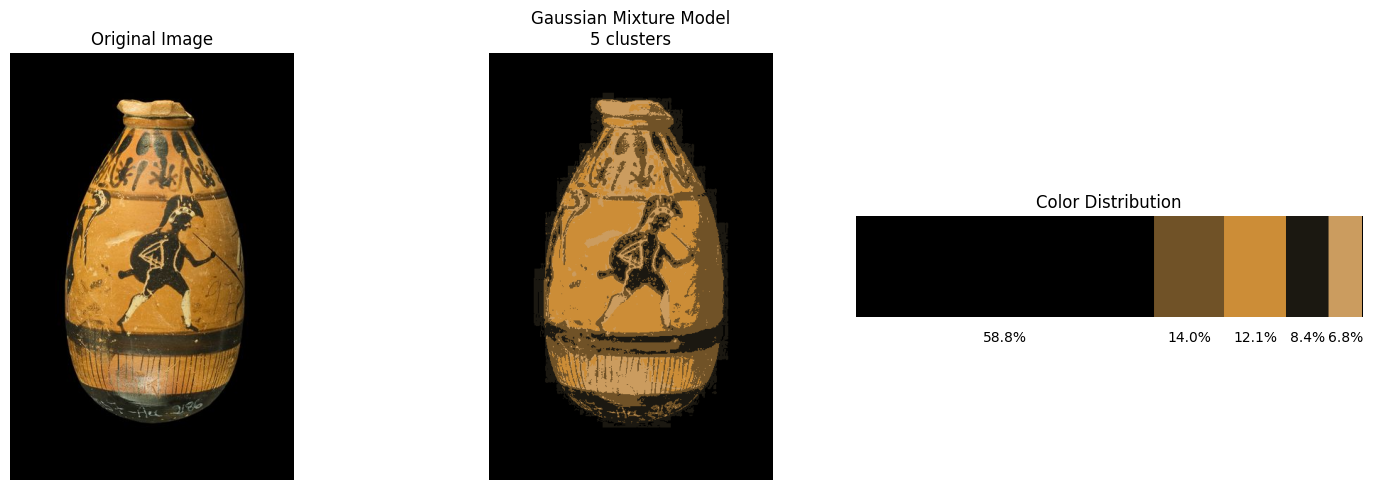

In [9]:
analyze_gmm(image_path)

3. Mean Shift

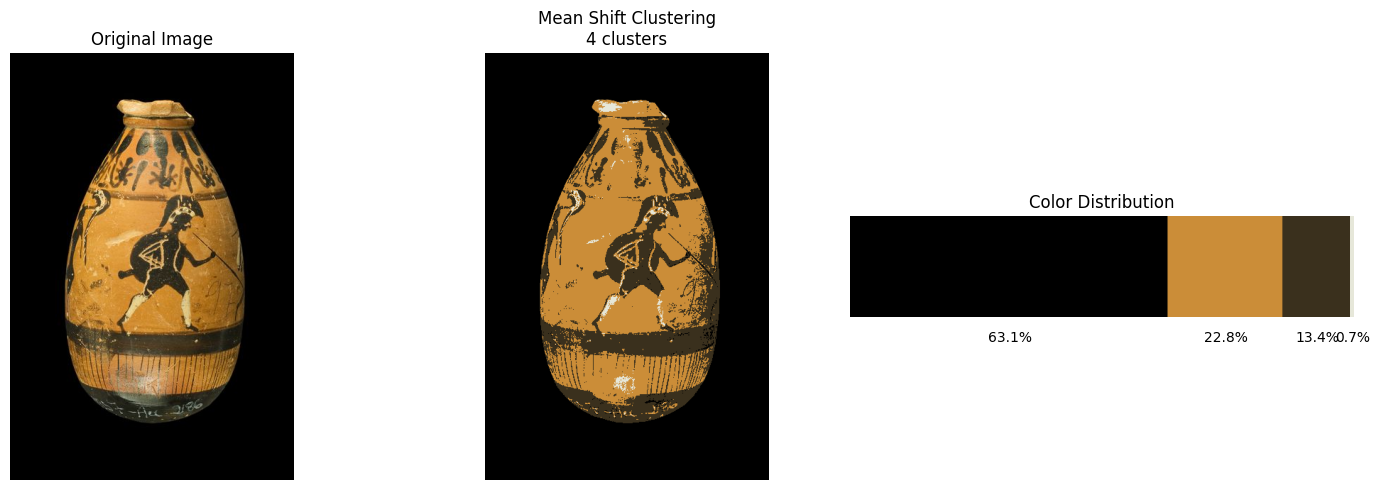

In [10]:
analyze_meanshift(image_path)

4. Agglomerative Clustering

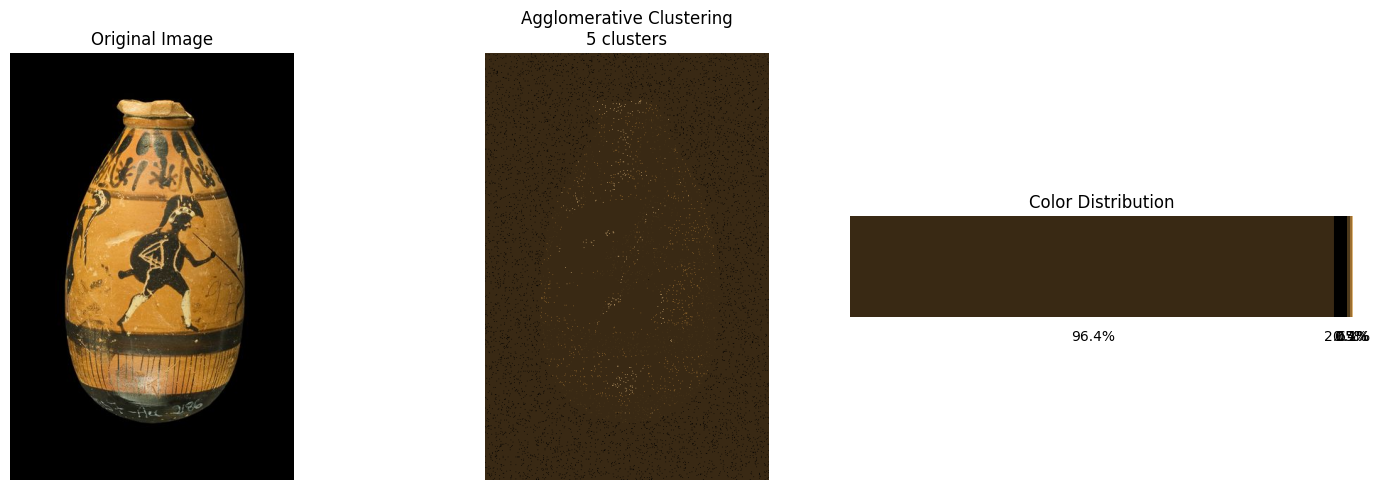

In [11]:
analyze_agglomerative(image_path)

5. DBSCAN

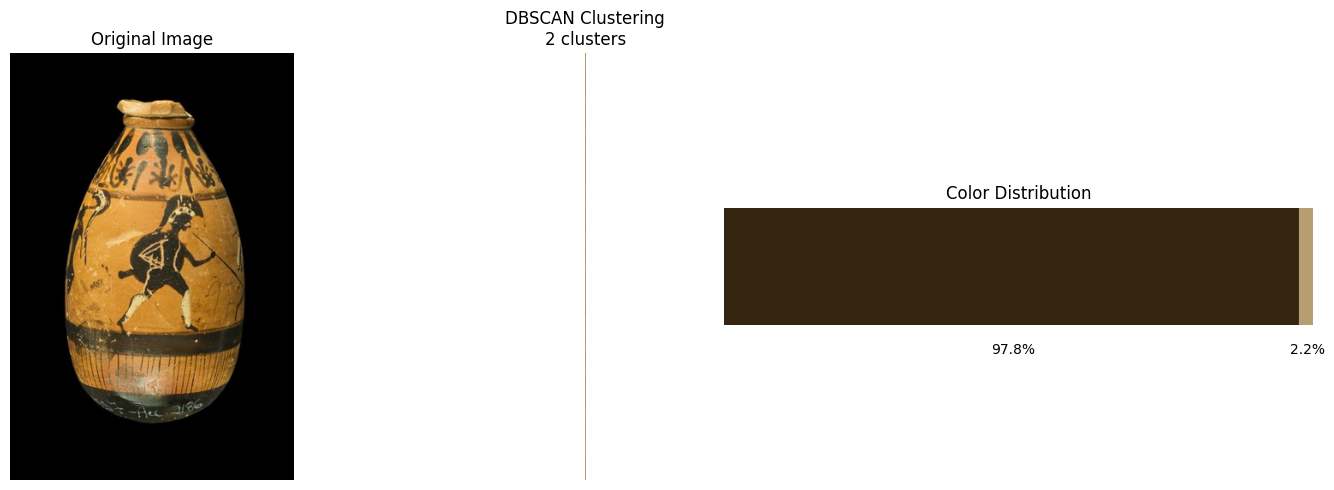

In [12]:
analyze_dbscan(image_path)

6. BIRCH

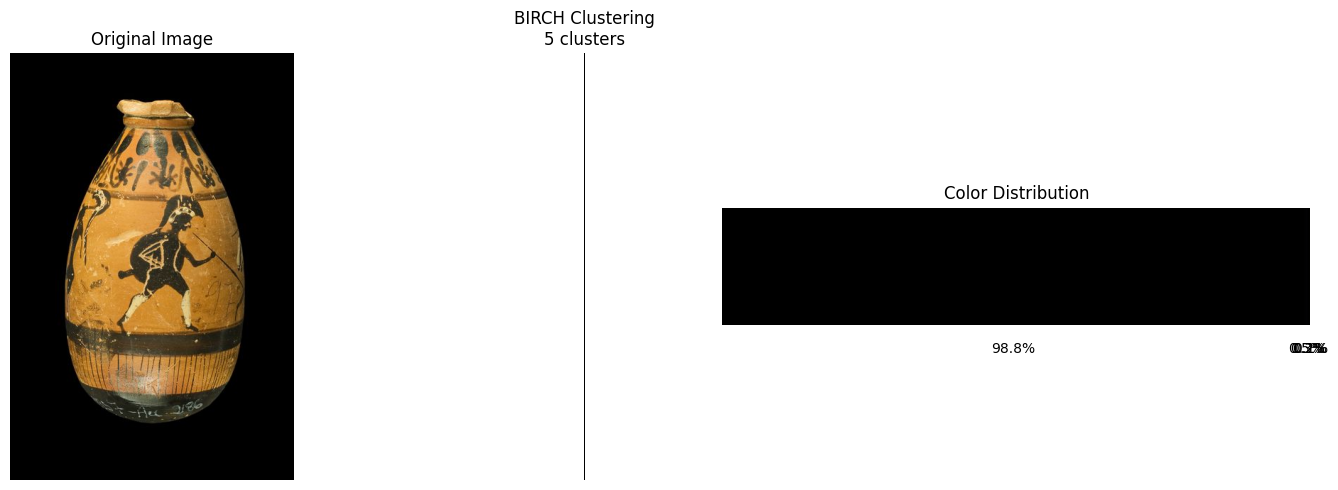

In [22]:
analyze_birch(image_path)

#### Result
___
Best Choice: K-Means Cluster or Gaussian Mixture Model

Rank and Reason:
1. K-Means Cluster
   - Faster Processing
   - Manage to keep Image Contrast
   - Define Background and Object better
2. Gaussian Mixture Model
   - Read Dominant Color better
   - Slower Processing